In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
train = pd.read_csv("../data/raw/train.csv")
test  = pd.read_csv("../data/raw/test.csv")

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("\nColumns:", train.columns.tolist())
train.head()

Train shape: (1549, 7)
Test shape:  (5, 7)

Columns: ['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus']


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00007637202177411956430,-4,2315,58.253649,79,Male,Ex-smoker
1,ID00007637202177411956430,5,2214,55.712129,79,Male,Ex-smoker
2,ID00007637202177411956430,7,2061,51.862104,79,Male,Ex-smoker
3,ID00007637202177411956430,9,2144,53.950679,79,Male,Ex-smoker
4,ID00007637202177411956430,11,2069,52.063412,79,Male,Ex-smoker


In [7]:
print("=== Patient counts ===")
print(f"Train patients : {train['Patient'].nunique()}")
print(f"Test  patients : {test['Patient'].nunique()}")

print("\n=== FVC stats ===")
print(train["FVC"].describe())

print("\n=== Missing values ===")
print(train.isnull().sum())

print("\n=== Smoking status breakdown ===")
print(train.groupby("Patient")["SmokingStatus"].first().value_counts())

print("\n=== Sex breakdown ===")
print(train.groupby("Patient")["Sex"].first().value_counts())

=== Patient counts ===
Train patients : 176
Test  patients : 5

=== FVC stats ===
count    1549.000000
mean     2690.479019
std       832.770959
min       827.000000
25%      2109.000000
50%      2641.000000
75%      3171.000000
max      6399.000000
Name: FVC, dtype: float64

=== Missing values ===
Patient          0
Weeks            0
FVC              0
Percent          0
Age              0
Sex              0
SmokingStatus    0
dtype: int64

=== Smoking status breakdown ===
SmokingStatus
Ex-smoker           118
Never smoked         49
Currently smokes      9
Name: count, dtype: int64

=== Sex breakdown ===
Sex
Male      139
Female     37
Name: count, dtype: int64


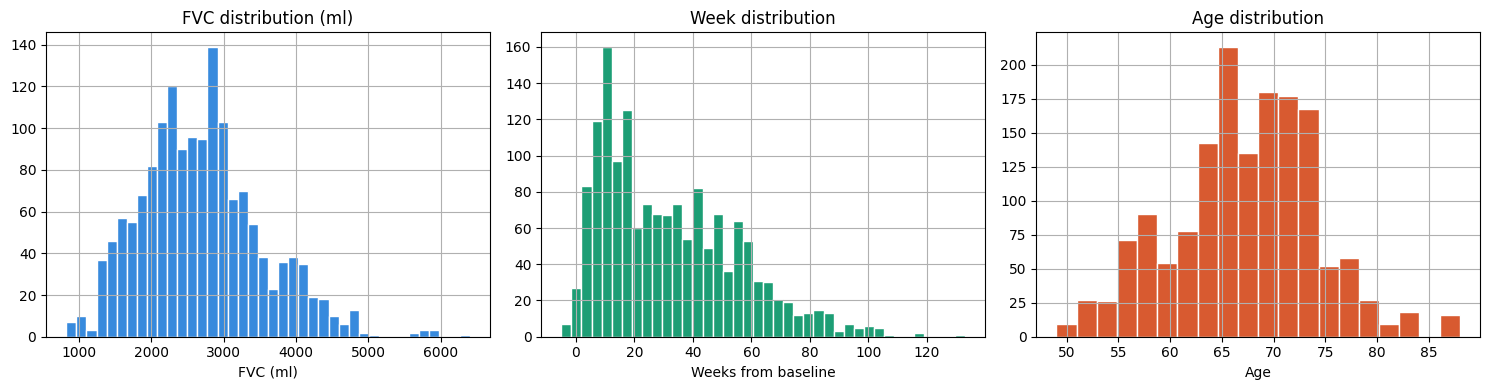

Saved to outputs/eda_distributions.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train["FVC"].hist(ax=axes[0], bins=40, color="#378ADD", edgecolor="white")
axes[0].set_title("FVC distribution (ml)")
axes[0].set_xlabel("FVC (ml)")

train["Weeks"].hist(ax=axes[1], bins=40, color="#1D9E75", edgecolor="white")
axes[1].set_title("Week distribution")
axes[1].set_xlabel("Weeks from baseline")

train["Age"].hist(ax=axes[2], bins=20, color="#D85A30", edgecolor="white")
axes[2].set_title("Age distribution")
axes[2].set_xlabel("Age")

plt.tight_layout()
plt.savefig("../outputs/eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/eda_distributions.png")

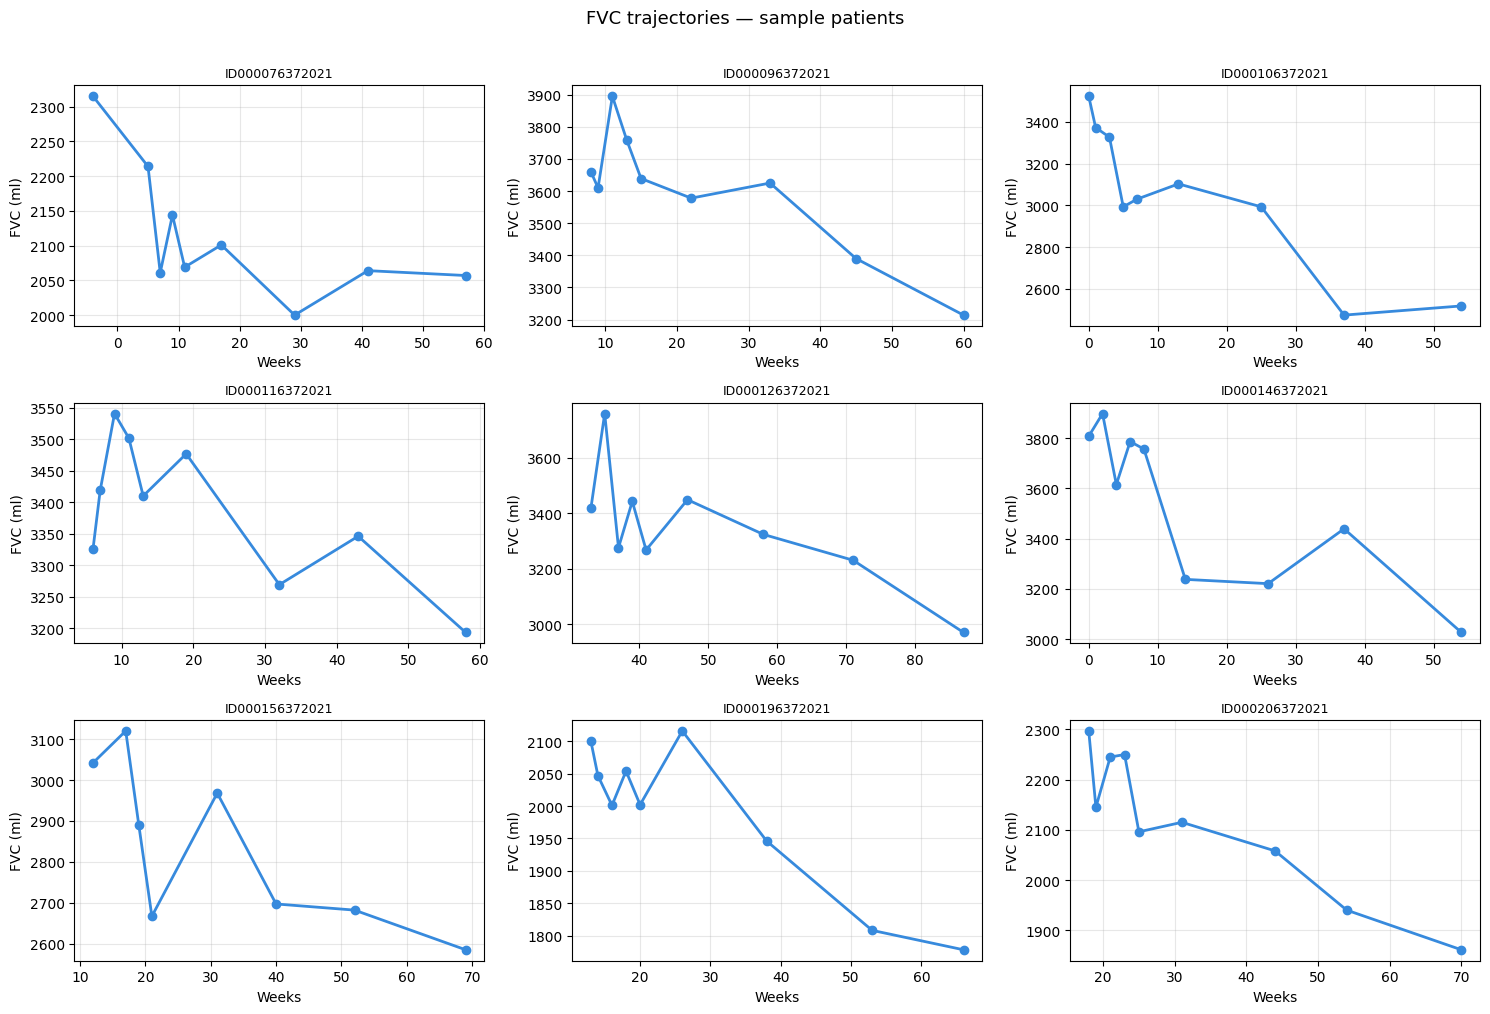

In [9]:
sample_pids = train["Patient"].unique()[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, pid in zip(axes.flatten(), sample_pids):
    p = train[train["Patient"] == pid].sort_values("Weeks")
    ax.plot(p["Weeks"], p["FVC"], marker="o", linewidth=2, color="#378ADD")
    ax.set_title(f"{pid[:14]}", fontsize=9)
    ax.set_xlabel("Weeks")
    ax.set_ylabel("FVC (ml)")
    ax.grid(True, alpha=0.3)

plt.suptitle("FVC trajectories — sample patients", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/eda_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

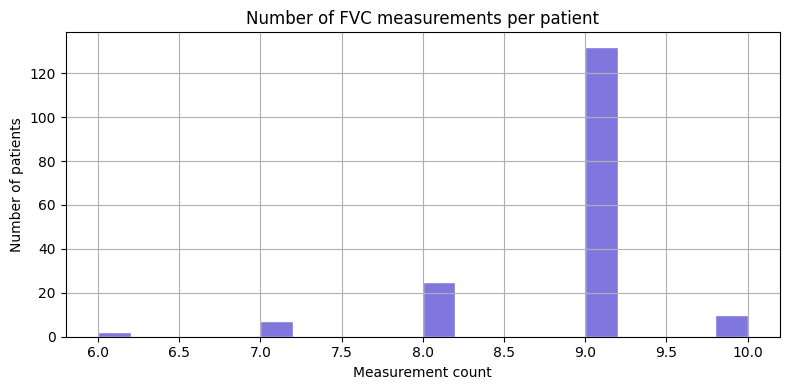

Min measurements : 6
Max measurements : 10
Mean measurements: 8.8


In [10]:
measurements_per_patient = train.groupby("Patient")["Weeks"].count()

fig, ax = plt.subplots(figsize=(8, 4))
measurements_per_patient.hist(bins=20, ax=ax, color="#7F77DD", edgecolor="white")
ax.set_title("Number of FVC measurements per patient")
ax.set_xlabel("Measurement count")
ax.set_ylabel("Number of patients")
plt.tight_layout()
plt.savefig("../outputs/eda_measurements.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Min measurements : {measurements_per_patient.min()}")
print(f"Max measurements : {measurements_per_patient.max()}")
print(f"Mean measurements: {measurements_per_patient.mean():.1f}")

C:\Users\Balaji Ranganathan\AppData\Local\Temp\ipykernel_6260\70919446.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = train.groupby("Patient").apply(fvc_slope)


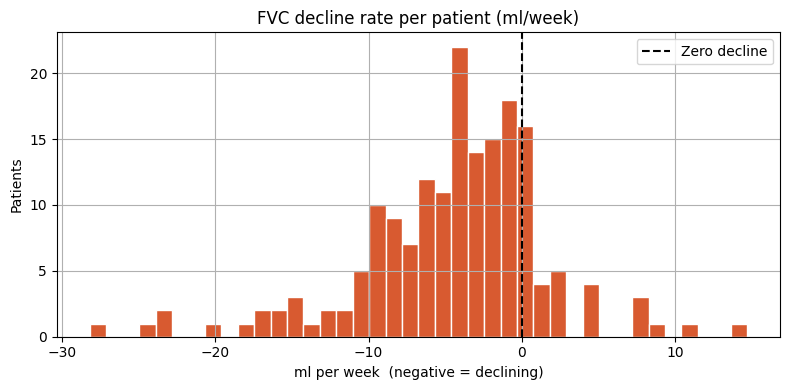

Patients with declining FVC : 147 / 176
Mean decline rate           : -4.52 ml/week
Median decline rate         : -3.91 ml/week


In [13]:
# How much does FVC actually decline over the study period?
def fvc_slope(group):
    group = group.sort_values("Weeks")
    if len(group) < 2:
        return np.nan
    weeks = group["Weeks"].values
    fvc   = group["FVC"].values
    # ml per week
    return np.polyfit(weeks, fvc, 1)[0]

slopes = train.groupby("Patient").apply(fvc_slope)

fig, ax = plt.subplots(figsize=(8, 4))
slopes.hist(bins=40, ax=ax, color="#D85A30", edgecolor="white")
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", label="Zero decline")
ax.set_title("FVC decline rate per patient (ml/week)")
ax.set_xlabel("ml per week  (negative = declining)")
ax.set_ylabel("Patients")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/eda_slopes.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Patients with declining FVC : {(slopes < 0).sum()} / {len(slopes)}")
print(f"Mean decline rate           : {slopes.mean():.2f} ml/week")
print(f"Median decline rate         : {slopes.median():.2f} ml/week")